In [1]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy streamlit


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pillow-11.2.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-manylinux2014_x86_64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached charset_normalizer-3.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86

In [3]:
pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 1.7 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
# --- Import Required Libraries ---
# Data manipulation
import pandas as pd         # For structured data manipulation
import numpy as np          # For numerical computations

# Visualization
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns            # For statistical visualizations

# DICOM handling
import pydicom                # To read DICOM image files
from pydicom.multival import MultiValue  # Handles multi-valued DICOM fields

# Image handling
from PIL import Image         # For resizing/saving images

# Display tools
from IPython.display import HTML, display  # For HTML rendering in notebooks
import os  # For interacting with the file system

In [5]:
df_pnemonia= pd.read_csv('/home/samyak/PycharmProjects/Pneumonia-Detection/dataset/Patient_dataset_extract.csv')
patient_info_table= pd.read_csv('/home/samyak/PycharmProjects/Pneumonia-Detection/dataset/Patient_xray_metadata.csv')

Visualization


/tmp/ipykernel_6220/660350544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df_pnemonia, x='class', order=df_pnemonia['class'].value_counts().index, palette='Set3')


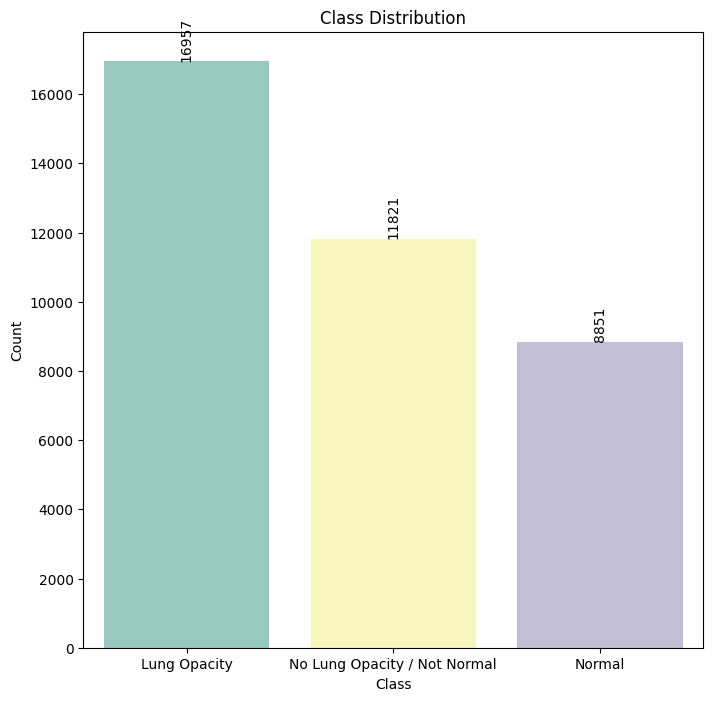

In [6]:
plt.figure(figsize=(8, 8))
ax=sns.countplot(data=df_pnemonia, x='class', order=df_pnemonia['class'].value_counts().index, palette='Set3')
# Add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        rotation=90
    )
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

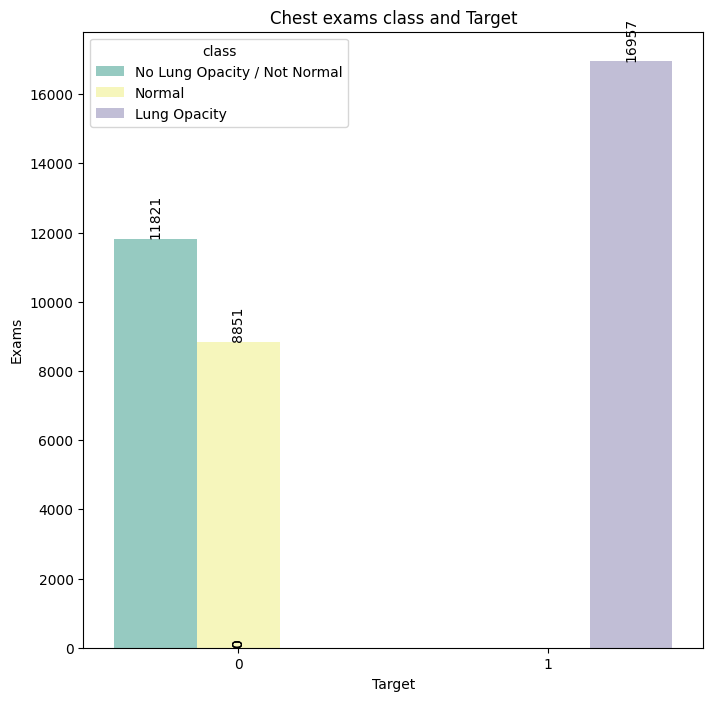

In [7]:
fig, ax = plt.subplots(nrows=1,figsize=(8,8))
tmp = df_pnemonia.groupby('Target')['class'].value_counts()
df = pd.DataFrame(data={'Exams': tmp.values}, index=tmp.index).reset_index()
ax= sns.barplot(ax=ax,x = 'Target', y='Exams',hue='class',data=df, palette='Set3')
# Add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        rotation=90
    )
plt.title("Chest exams class and Target")
plt.show()

In [8]:
df_label_vis= df_pnemonia.copy()

In [9]:
# Number of entries in Train label dataframe:
print('The train_label dataframe has {} rows and {} columns.'.format(df_label_vis.shape[0], df_label_vis.shape[1]))

The train_label dataframe has 37629 rows and 19 columns.


In [10]:
# Number of duplicates in patientId:
print('Number of unique patientId are: {}'.format(df_label_vis['patientId'].nunique()))

Number of unique patientId are: 26684


In [11]:
df_label_vis.drop_duplicates('patientId').shape[0]

26684

In [12]:
one = df_label_vis[df_label_vis.Target == 1].drop_duplicates('patientId').shape[0]
zero = df_label_vis[df_label_vis.Target == 0].drop_duplicates('patientId').shape[0]
total = df_label_vis.drop_duplicates('patientId').shape[0]

Number of entries with Pneumonia: 6012 (23.0%)
Number of entries without Pneumonia: 20672 (77.0%)


<Axes: title={'center': 'Pneumonia Class Distribution'}, ylabel='count'>

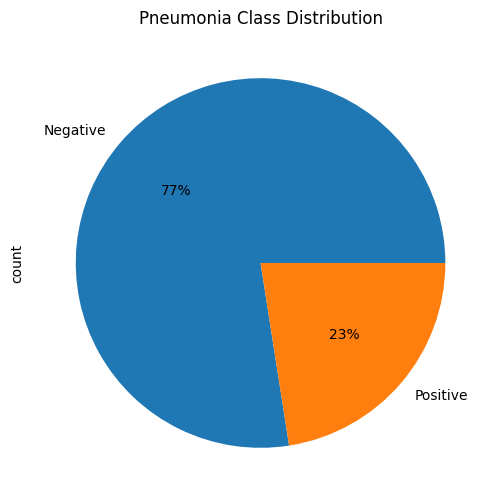

In [13]:
# Calculate total entries and class counts


# Print class distribution with percentages
print(f"Number of entries with Pneumonia: {one} ({round(one / total * 100, 0)}%)")
print(f"Number of entries without Pneumonia: {zero} ({round(zero / total * 100, 0)}%)")

# Plot class distribution as a pie chart
df_label_vis.drop_duplicates('patientId')['Target'].value_counts().plot(
    kind='pie',
    autopct='%.0f%%',
    labels=['Negative', 'Positive'],
    figsize=(10, 6),
    title='Pneumonia Class Distribution'
)


In [14]:
# Checking nulls in bounding box columns:
print('Number of nulls in bounding box columns: {}'.format(df_label_vis[['x', 'y', 'width', 'height']].isnull().sum().to_dict()))

Number of nulls in bounding box columns: {'x': 0, 'y': 0, 'width': 0, 'height': 0}


Thus, there are 23286 unique patients which have only one entry in the dataset. It also has the patientsbounding box, 3266 with 2 bounding box, 119 with 3 bounding box and 13 with 4 bounding box coordinates.

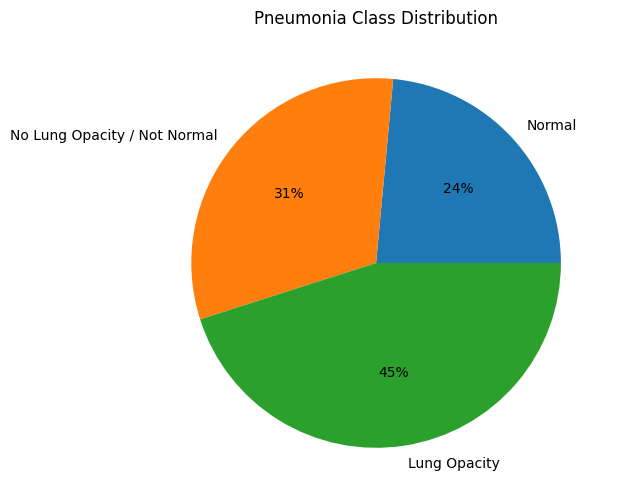

In [15]:
import matplotlib.pyplot as plt

# Plot pie chart of class distribution
plt.figure(figsize=(10, 6))  # Set figure size
df_pnemonia['class'].value_counts().sort_index(ascending=False).plot(
    kind='pie',
    autopct='%.0f%%',
    labels=df_pnemonia['class'].value_counts().sort_index(ascending=False).index,
    ylabel='',  # Removes the default y-label
    title='Pneumonia Class Distribution'
)
plt.show()


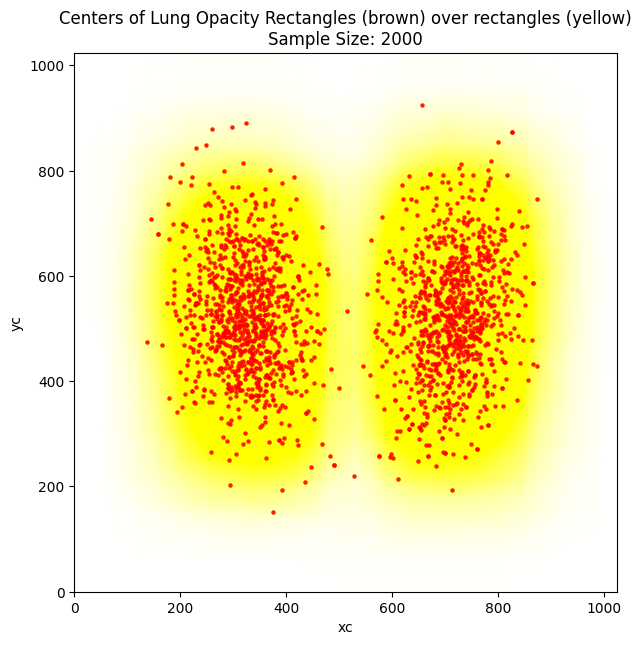

In [16]:
from matplotlib.patches import Rectangle


fig, ax = plt.subplots(1, 1, figsize = (7, 7))
target_1 = df_pnemonia[df_pnemonia['Target'] == 1]
target_sample = target_1.sample(2000)
target_sample['xc'] = target_sample['x'] + target_sample['width'] / 2
target_sample['yc'] = target_sample['y'] + target_sample['height'] / 2
plt.title('Centers of Lung Opacity Rectangles (brown) over rectangles (yellow)\nSample Size: 2000')
target_sample.plot.scatter(x = 'xc', y = 'yc', xlim = (0, 1024), ylim = (0, 1024), ax = ax, alpha = 0.8, marker = '.', color = 'red')

for i, crt_sample in target_sample.iterrows():
    ax.add_patch(Rectangle(xy=(crt_sample['x'], crt_sample['y']),
                width=crt_sample['width'],height=crt_sample['height'],alpha=3.5e-3, color="yellow"))

/tmp/ipykernel_6220/2269091860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.countplot(data=df_pnemonia, x='Target', order=df_pnemonia['Target'].value_counts().index, palette='Set3')


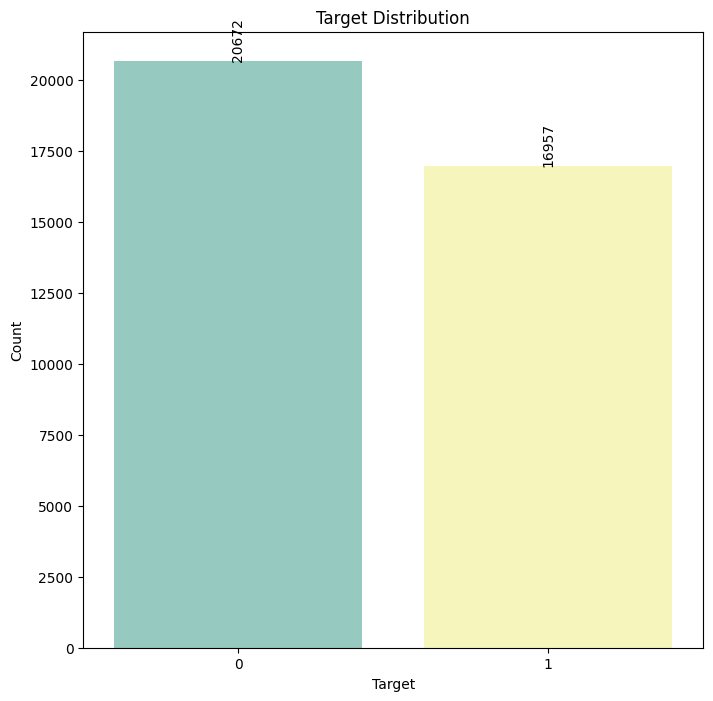

In [17]:
plt.figure(figsize=(8, 8))
ax= sns.countplot(data=df_pnemonia, x='Target', order=df_pnemonia['Target'].value_counts().index, palette='Set3')
# Add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        rotation=90
    )
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [18]:
df_pnemonia.columns

Index(['patientId', 'x', 'y', 'width', 'height', 'Target', 'number_of_boxes',
       'class', 'path', 'modality', 'PatientSex', 'PatientAge',
       'BodyPartExamined', 'Rows', 'Columns', 'ViewPosition', 'pixelSpacing_X',
       'pixelSpacing_Y', 'ConversionType'],
      dtype='object')

/tmp/ipykernel_6220/1889673484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=patient_info_table, x='PatientSex', order=df_pnemonia['PatientSex'].value_counts().index, palette='Set3')


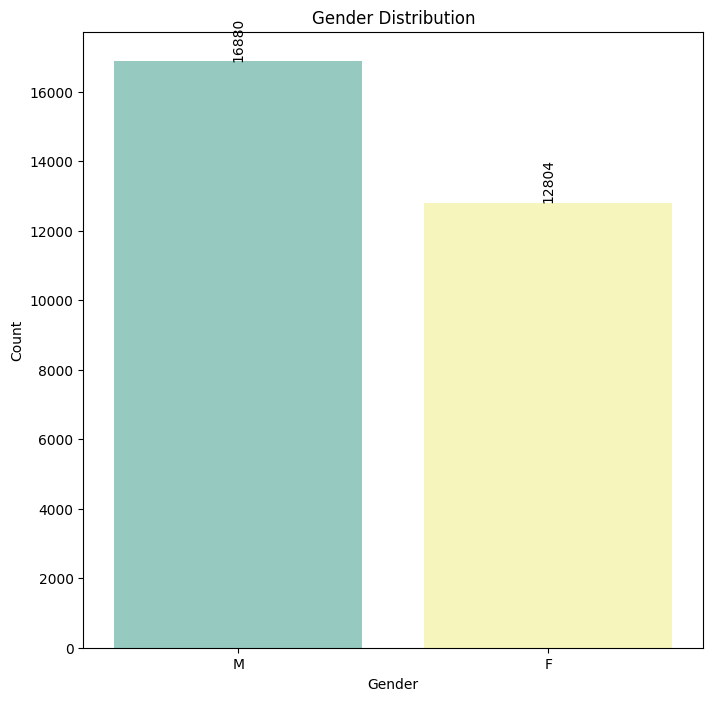

In [19]:
plt.figure(figsize=(8, 8))
ax=sns.countplot(data=patient_info_table, x='PatientSex', order=df_pnemonia['PatientSex'].value_counts().index, palette='Set3')
# Add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        rotation=90
    )
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [20]:
df_pnemonia.columns


Index(['patientId', 'x', 'y', 'width', 'height', 'Target', 'number_of_boxes',
       'class', 'path', 'modality', 'PatientSex', 'PatientAge',
       'BodyPartExamined', 'Rows', 'Columns', 'ViewPosition', 'pixelSpacing_X',
       'pixelSpacing_Y', 'ConversionType'],
      dtype='object')

/tmp/ipykernel_6220/1804095855.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=filtered_data, x='PatientAge', order=top_25_ages, palette='Set3')


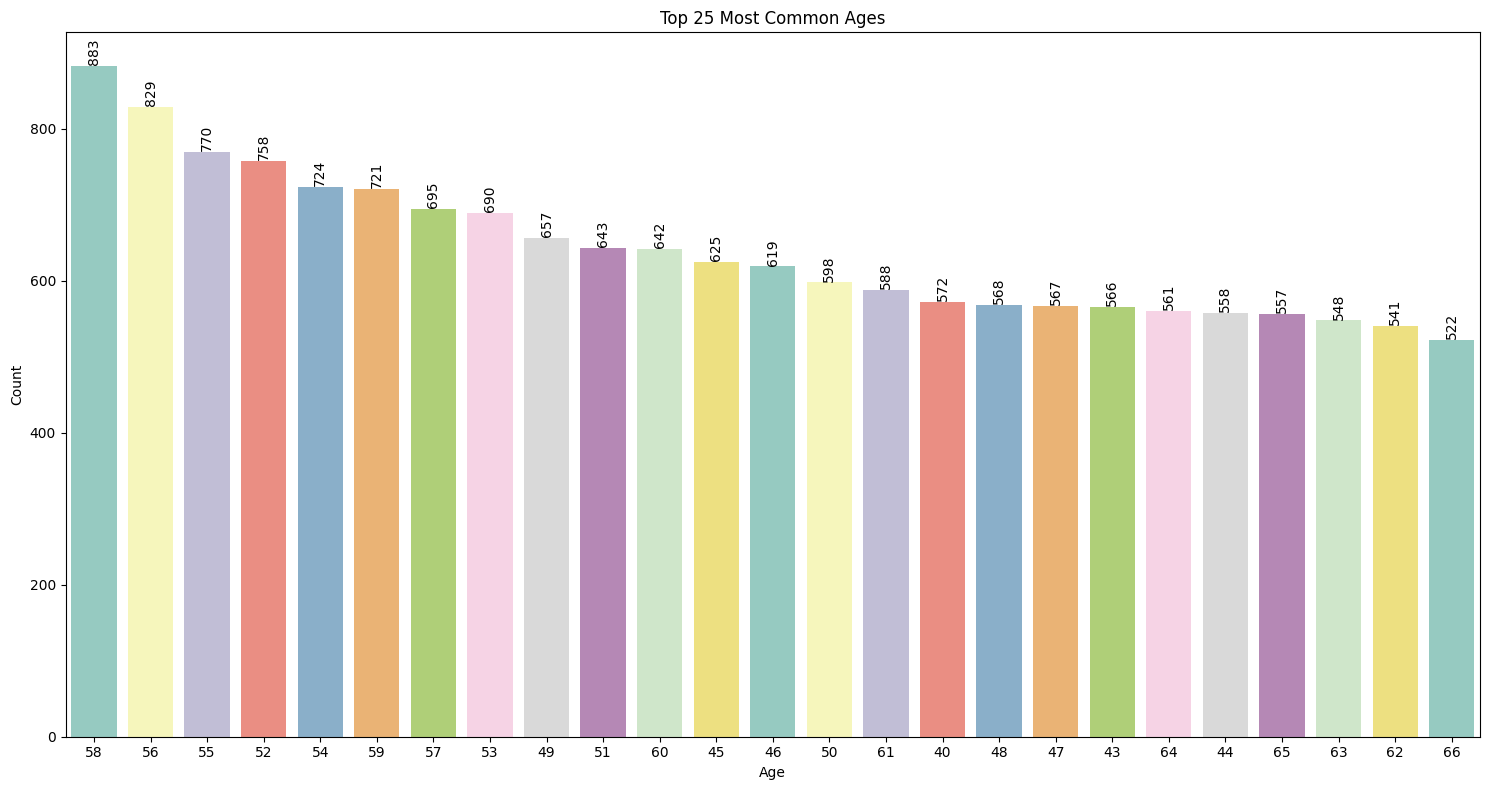

In [21]:
# Get top 25 most common ages
top_25_ages = patient_info_table['PatientAge'].value_counts().nlargest(25).index

# Filter the data to include only those top 25 ages
filtered_data = patient_info_table[patient_info_table['PatientAge'].isin(top_25_ages)]

# Plot
plt.figure(figsize=(15, 8))
ax = sns.countplot(data=filtered_data, x='PatientAge', order=top_25_ages, palette='Set3')

# Add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        rotation=90
    )

plt.title('Top 25 Most Common Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [22]:
df_pnemonia.columns

Index(['patientId', 'x', 'y', 'width', 'height', 'Target', 'number_of_boxes',
       'class', 'path', 'modality', 'PatientSex', 'PatientAge',
       'BodyPartExamined', 'Rows', 'Columns', 'ViewPosition', 'pixelSpacing_X',
       'pixelSpacing_Y', 'ConversionType'],
      dtype='object')

In [23]:
df_pnemonia_crr= df_pnemonia.copy()

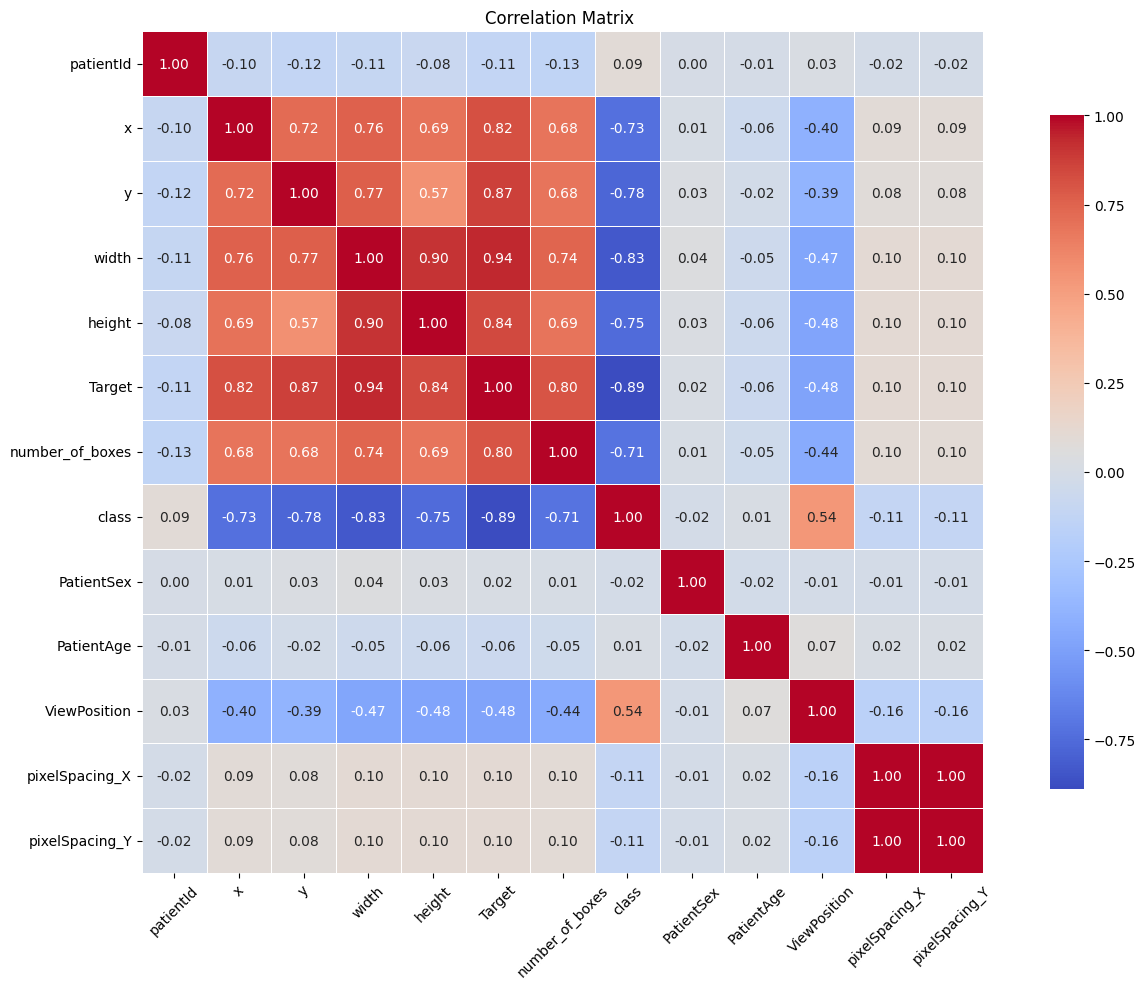

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Encode all categorical columns
encoded_data = df_pnemonia.copy()
encoded_data.drop(columns=['BodyPartExamined', 'Rows', 'Columns','modality','path','ConversionType'],inplace=True)
# Automatically convert object and category columns to numeric using label encoding
for col in encoded_data.select_dtypes(include=['object', 'category']):
    encoded_data[col] = encoded_data[col].astype('category').cat.codes

# Step 2: Compute correlation matrix on all columns
corr_matrix = encoded_data.corr()

# Step 3: Plot the correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix ')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
encoded_data

,patientId,x,y,width,height,Target,number_of_boxes,class,PatientSex,PatientAge,ViewPosition,pixelSpacing_X,pixelSpacing_Y
0,0,0.0,0.0,0.0,0.0,0,1,1,0,51,1,0.143000,0.143000
1,13,0.0,0.0,0.0,0.0,0,1,1,0,48,1,0.194311,0.194311
2,14,0.0,0.0,0.0,0.0,0,1,1,1,19,0,0.168000,0.168000
3,15,0.0,0.0,0.0,0.0,0,1,2,1,28,1,0.143000,0.143000
4,16,264.0,152.0,213.0,379.0,1,2,0,0,32,0,0.139000,0.139000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37624,19463,0.0,0.0,0.0,0.0,0,1,2,1,45,1,0.168000,0.168000
37625,19464,570.0,393.0,261.0,345.0,1,2,0,0,72,0,0.139000,0.139000
37626,19464,233.0,424.0,201.0,356.0,1,2,0,0,72,0,0.139000,0.139000
37627,19464,570.0,393.0,261.0,345.0,1,2,0,0,72,0,0.139000,0.139000


In [26]:
df_pnemonia = df_pnemonia.drop_duplicates(subset=['patientId'])


In [27]:
df_pnemonia.shape

(26684, 19)

In [28]:
# Keep the last duplicate instead of the first (default)
df_pnemonia = df_pnemonia.drop_duplicates(keep='last')


In [29]:
df_pnemonia.shape

(26684, 19)

In [30]:

# Save DataFrame to CSV
#file_path = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection\patient_diagnosis.csv"
#df_merged.to_csv(file_path, index=False)



In [31]:
df_pnemonia.isnull().sum()

patientId           0
x                   0
y                   0
width               0
height              0
Target              0
number_of_boxes     0
class               0
path                0
modality            0
PatientSex          0
PatientAge          0
BodyPartExamined    0
Rows                0
Columns             0
ViewPosition        0
pixelSpacing_X      0
pixelSpacing_Y      0
ConversionType      0
dtype: int64

/tmp/ipykernel_6220/2821998431.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(target1['x'],kde=True,bins=50, color="red", ax=ax[0,0])
/tmp/ipykernel_6220/2821998431.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(target1['y'],kde=True,bins=50, color="blue", ax=ax[0,1])
/tmp/ipykernel_62

<Figure size 640x480 with 0 Axes>

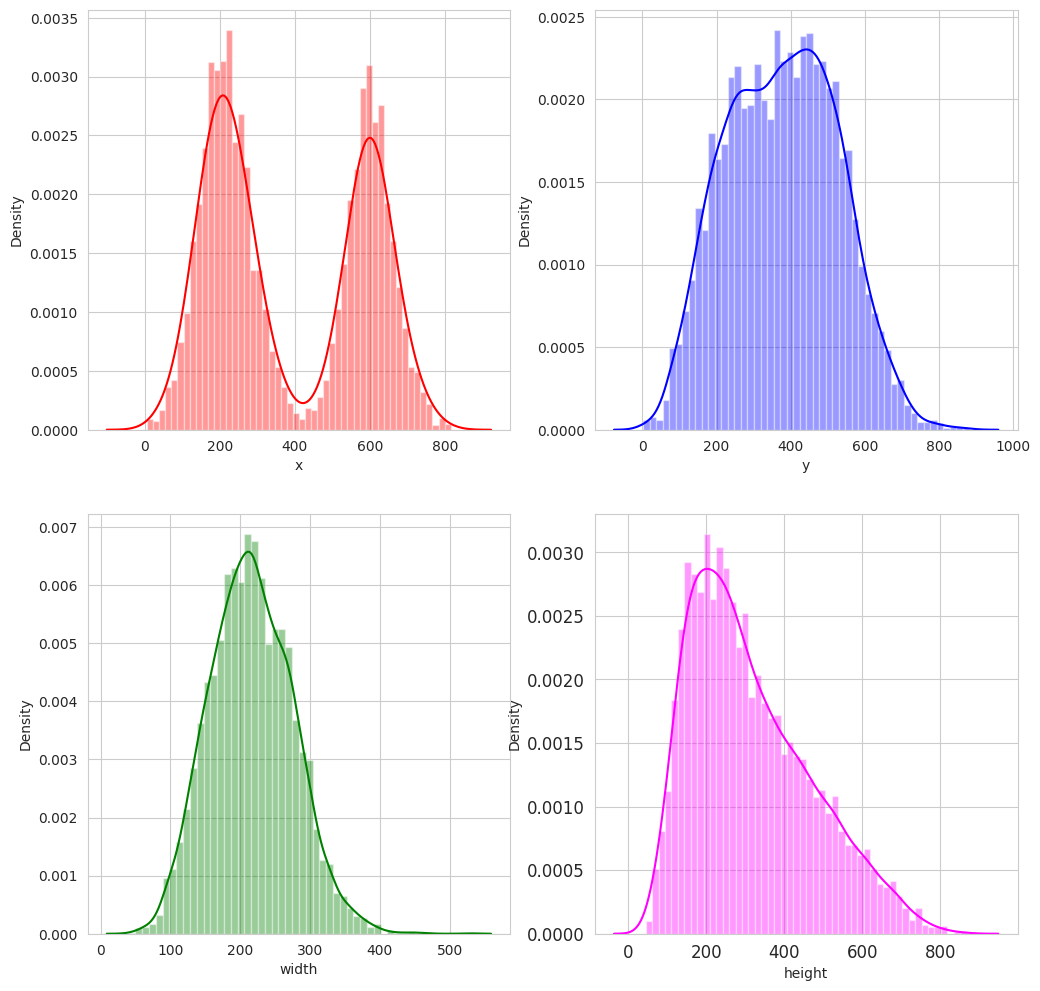

In [32]:
target1 = df_pnemonia[df_pnemonia['Target']==1]
sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(2,2,figsize=(12,12))
sns.distplot(target1['x'],kde=True,bins=50, color="red", ax=ax[0,0])
sns.distplot(target1['y'],kde=True,bins=50, color="blue", ax=ax[0,1])
sns.distplot(target1['width'],kde=True,bins=50, color="green", ax=ax[1,0])
sns.distplot(target1['height'],kde=True,bins=50, color="magenta", ax=ax[1,1])
#sns.distplot(target1['pixelSpacing_X'],kde=True,bins=50, color="yellow", ax=ax[2,0])
#sns.distplot(target1['pixelSpacing_Y'],kde=True,bins=50, color="magenta", ax=ax[2,2])
locs, labels = plt.xticks()
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

In [33]:
df_pnemonia.columns

Index(['patientId', 'x', 'y', 'width', 'height', 'Target', 'number_of_boxes',
       'class', 'path', 'modality', 'PatientSex', 'PatientAge',
       'BodyPartExamined', 'Rows', 'Columns', 'ViewPosition', 'pixelSpacing_X',
       'pixelSpacing_Y', 'ConversionType'],
      dtype='object')

In [34]:
print('Removing the outliers from `PatientAge`')
df_pnemonia['PatientAge'] = df_pnemonia['PatientAge'].clip(df_pnemonia['PatientAge'].min(), 100)
df_pnemonia['PatientAge'].describe().astype(int)

Removing the outliers from `PatientAge`


count    26684
mean        47
std         16
min          1
25%         34
50%         49
75%         59
max        100
Name: PatientAge, dtype: int64

Distribution of Patient Age: Overall and Target =1


/tmp/ipykernel_6220/5761666.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g = (sns.distplot(df_pnemonia['PatientAge']).set_title('Distribution of PatientAge'))
/tmp/ipykernel_6220/5761666.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g = (sns.distplot(df_pnemonia.drop_duplicates('patientId').loc[df_pnemonia['

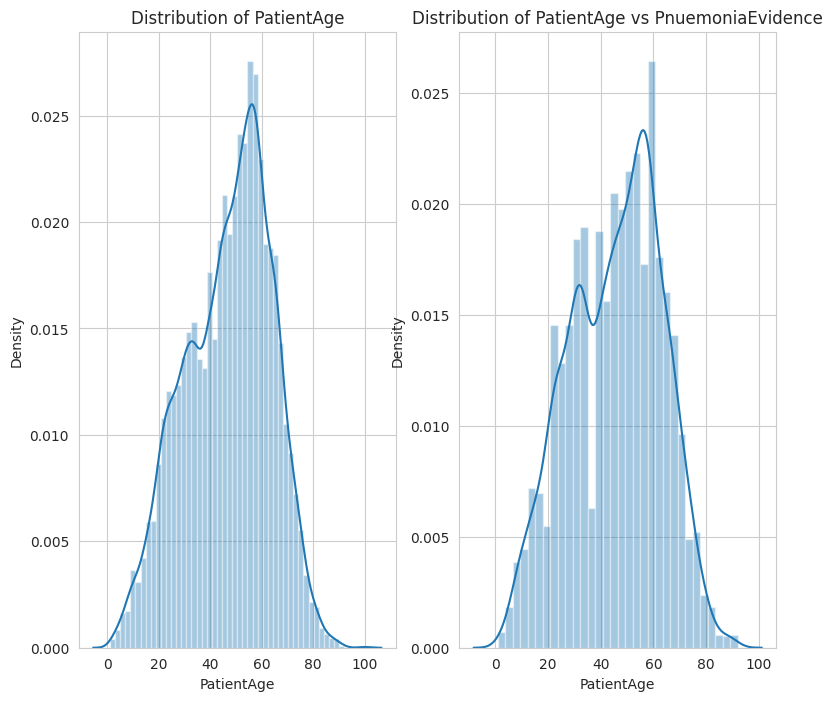

In [35]:
print("Distribution of Patient Age: Overall and Target =1")
fig=plt.figure(figsize=(9,8))
ax= fig.add_subplot(121)
g = (sns.distplot(df_pnemonia['PatientAge']).set_title('Distribution of PatientAge'))

ax = fig.add_subplot(122)
g = (sns.distplot(df_pnemonia.drop_duplicates('patientId').loc[df_pnemonia['Target'] == 1, 'PatientAge']).set_title('Distribution of PatientAge vs PnuemoniaEvidence'))

In [36]:
df_pnemonia

,patientId,x,y,width,height,Target,number_of_boxes,class,path,modality,PatientSex,PatientAge,BodyPartExamined,Rows,Columns,ViewPosition,pixelSpacing_X,pixelSpacing_Y,ConversionType
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0.0,0.0,0.0,0.0,0,1,No Lung Opacity / Not Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,51,CHEST,1024,1024,PA,0.143000,0.143000,WSD
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0.0,0.0,0.0,0.0,0,1,No Lung Opacity / Not Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,48,CHEST,1024,1024,PA,0.194311,0.194311,WSD
2,00322d4d-1c29-4943-afc9-b6754be640eb,0.0,0.0,0.0,0.0,0,1,No Lung Opacity / Not Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,M,19,CHEST,1024,1024,AP,0.168000,0.168000,WSD
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0.0,0.0,0.0,0.0,0,1,Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,M,28,CHEST,1024,1024,PA,0.143000,0.143000,WSD
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,2,Lung Opacity,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,32,CHEST,1024,1024,AP,0.139000,0.139000,WSD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37615,c1e73a4e-7afe-4ec5-8af6-ce8315d7a2f2,666.0,418.0,186.0,223.0,1,2,Lung Opacity,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,47,CHEST,1024,1024,AP,0.168000,0.168000,WSD
37619,c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8,609.0,464.0,240.0,284.0,1,2,Lung Opacity,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,M,54,CHEST,1024,1024,AP,0.139000,0.139000,WSD
37623,c1edf42b-5958-47ff-a1e7-4f23d99583ba,0.0,0.0,0.0,0.0,0,1,Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,46,CHEST,1024,1024,PA,0.143000,0.143000,WSD
37624,c1f6b555-2eb1-4231-98f6-50a963976431,0.0,0.0,0.0,0.0,0,1,Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,M,45,CHEST,1024,1024,PA,0.168000,0.168000,WSD


In [37]:
custom_array = np.linspace(0, 100, 11)
df_pnemonia['PatientAgeBins'] = pd.cut(df_pnemonia['PatientAge'], custom_array)
df_pnemonia.drop_duplicates('patientId')['PatientAgeBins'].value_counts()

PatientAgeBins
(50.0, 60.0]     6619
(40.0, 50.0]     5048
(60.0, 70.0]     4279
(30.0, 40.0]     3936
(20.0, 30.0]     3205
(10.0, 20.0]     1468
(70.0, 80.0]     1452
(0.0, 10.0]       435
(80.0, 90.0]      233
(90.0, 100.0]       9
Name: count, dtype: int64

In [38]:
age_25 = np.percentile(df_pnemonia['PatientAge'], 25)
age_75 = np.percentile(df_pnemonia['PatientAge'], 75)
iqr_age = age_75 - age_25
cutoff_age = 1.5 * iqr_age

In [39]:
low_lim_age = age_25 - cutoff_age
upp_lim_age = age_75 + cutoff_age

In [40]:
df_pnemonia['PatientAge'].value_counts()

PatientAge
58     798
56     755
55     701
52     692
54     638
      ... 
89       7
100      5
1        2
92       2
91       2
Name: count, Length: 93, dtype: int64

The number of outliers in `PatientAge` out of 30277 records are:  5

The ages which are in the outlier categories are: [100, 100, 100, 100, 100]


Text(0.5, 1.0, 'Outliers in PatientAge')

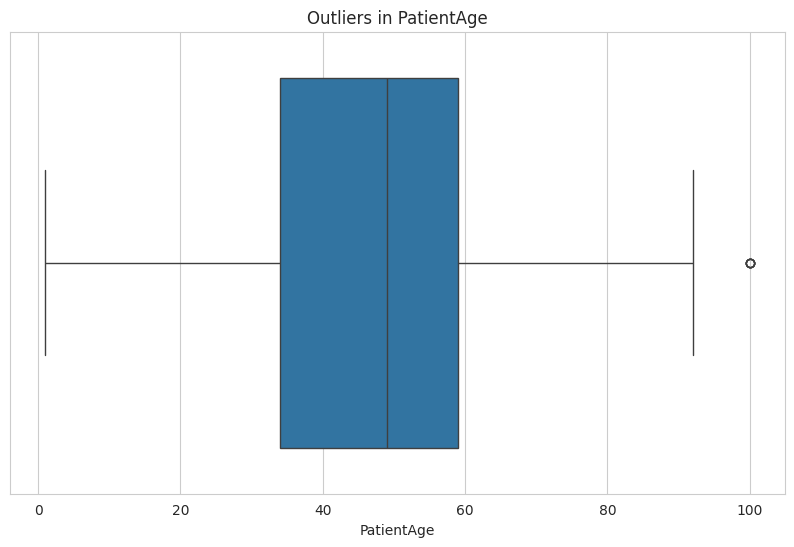

In [41]:
outlier_age = [x for x in df_pnemonia['PatientAge'] if x < low_lim_age or x > upp_lim_age]
print('The number of outliers in `PatientAge` out of 30277 records are: ', len(outlier_age))
print('\nThe ages which are in the outlier categories are:', outlier_age)

fig = plt.figure(figsize = (10, 6))
sns.boxplot(df_pnemonia['PatientAge'], orient = 'h').set_title('Outliers in PatientAge')

In [42]:
print('After adding the bin column, the dataset turns out to be:\n')
df_pnemonia.head()

After adding the bin column, the dataset turns out to be:



,patientId,x,y,width,height,Target,number_of_boxes,class,path,modality,PatientSex,PatientAge,BodyPartExamined,Rows,Columns,ViewPosition,pixelSpacing_X,pixelSpacing_Y,ConversionType,PatientAgeBins
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0.0,0.0,0.0,0.0,0,1,No Lung Opacity / Not Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,51,CHEST,1024,1024,PA,0.143000,0.143000,WSD,"(50.0, 60.0]"
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0.0,0.0,0.0,0.0,0,1,No Lung Opacity / Not Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,48,CHEST,1024,1024,PA,0.194311,0.194311,WSD,"(40.0, 50.0]"
2,00322d4d-1c29-4943-afc9-b6754be640eb,0.0,0.0,0.0,0.0,0,1,No Lung Opacity / Not Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,M,19,CHEST,1024,1024,AP,0.168000,0.168000,WSD,"(10.0, 20.0]"
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0.0,0.0,0.0,0.0,0,1,Normal,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,M,28,CHEST,1024,1024,PA,0.143000,0.143000,WSD,"(20.0, 30.0]"
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,2,Lung Opacity,C:\Users\samya\PyCharmProject\Pneumonia-Detect...,CR,F,32,CHEST,1024,1024,AP,0.139000,0.139000,WSD,"(30.0, 40.0]"


In [43]:
df_pnemonia.shape

(26684, 20)

In [44]:
print('Modality for the images obtained is: {} \n'.format(df_pnemonia['modality'].unique()[0]))

Modality for the images obtained is: CR 



As seen above, two View Positions that are in the training dataset are AP (Anterior/Posterior) and PA (Posterior/Anterior). These type of X-rays are mostly used to obtain the front-view. Apart from front-view, a lateral image is usually taken to complement the front-view.

    Posterior/Anterior (PA): Here the chest radiograph is acquired by passing the X-Ray beam from the patient's posterior (back) part of the chest to the anterior (front) part. While obtaining the image patient is asked to stand with their chest against the film. In this image, the hear is on the right side of the image as one looks at it. These are of higher quality and assess the heart size more accurately

    Anterior/Posterior (AP): At times it is not possible for radiographers to acquire a PA chest X-ray. This is usually because the patient is too unwell to stand. In these images the size of Heart is exaggerated.

In [45]:
def get_feature_distribution(data, feature):
    # Get the count for each label
    label_counts = data[feature].value_counts()

    # Get total number of samples
    total_samples = len(data)

    # Count the number of items in each class
    print("Feature: {}".format(feature))
    for i in range(len(label_counts)):
        label = label_counts.index[i]
        count = label_counts.values[i]
        percent = int((count / total_samples) * 10000) / 100
        print("{:<30s}:   {} , {}%".format(label, count, percent))



In [46]:
get_feature_distribution(df_pnemonia.drop_duplicates('patientId'), 'ViewPosition')

Feature: ViewPosition
PA                            :   14511 , 54.38%
AP                            :   12173 , 45.61%


The distribution of View Position when there is an evidence of Pneumonia:



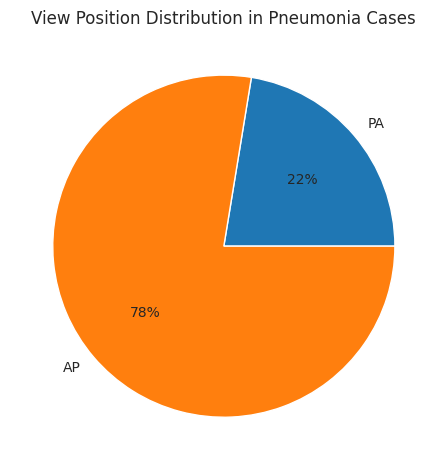

In [47]:
import matplotlib.pyplot as plt

# Print a title for the output
print('The distribution of View Position when there is an evidence of Pneumonia:\n')

# Step 1: Drop duplicate entries by patientId to ensure each patient is only counted once
unique_patients = df_pnemonia.drop_duplicates('patientId')

# Step 2: Filter rows where pneumonia is present (Target == 1)
pneumonia_cases = unique_patients[unique_patients['Target'] == 1]

# Step 3: Count the occurrences of each ViewPosition value and sort for consistent display
view_position_counts = pneumonia_cases['ViewPosition'].value_counts().sort_index(ascending=False)

# Step 4: Plot the distribution as a pie chart
view_position_counts.plot(
    kind='pie',
    autopct='%.0f%%',  # Show percentages with no decimal places
    ylabel=''           # Remove default y-axis label for cleaner look
)

# Step 5: Display the plot
plt.title('View Position Distribution in Pneumonia Cases')
plt.tight_layout()
plt.show()


Plot x and y centers of bounding box


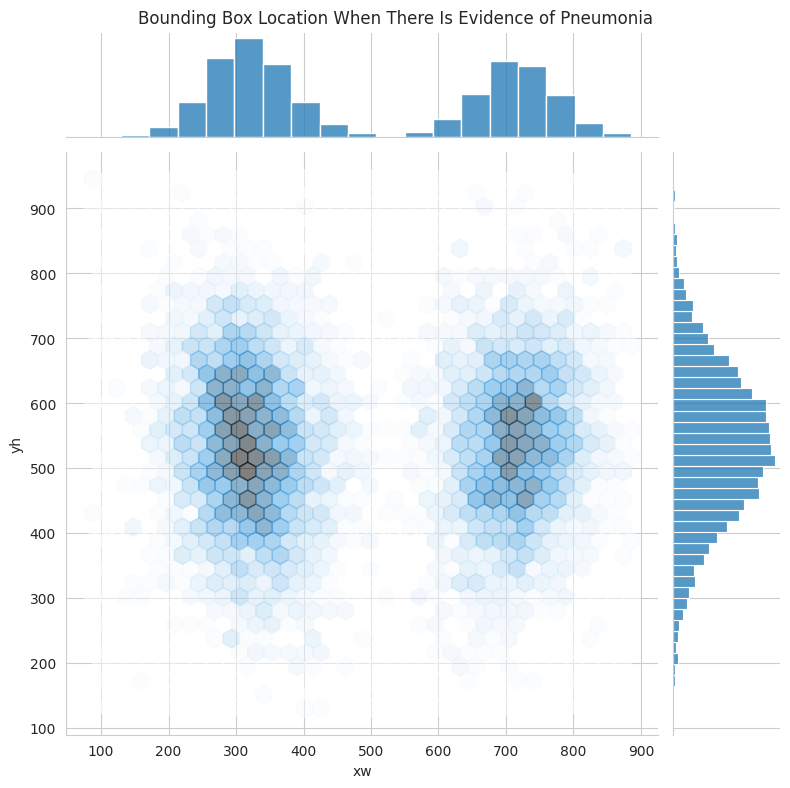

In [48]:


# Print a message describing the plot
print('Plot x and y centers of bounding box')

# Step 1: Filter rows where pneumonia is present (Target == 1)
bboxes = df_pnemonia[df_pnemonia['Target'] == 1].copy()

# Step 2: Calculate the center (x, y) of each bounding box
# xw: x center = x + width / 2
# yh: y center = y + height / 2
bboxes['xw'] = bboxes['x'] + bboxes['width'] / 2
bboxes['yh'] = bboxes['y'] + bboxes['height'] / 2

# Step 3: Plot a hexbin joint plot of the x and y centers of the bounding boxes
g = sns.jointplot(
    x='xw', y='yh', data=bboxes,     # Use xw and yh as coordinates
    kind='hex',                      # Hexbin plot shows density of points
    alpha=0.5,                       # Slight transparency for overlapping
    height=8                         # Size of the plot
)

# Step 4: Add a title and adjust layout
plt.suptitle('Bounding Box Location When There Is Evidence of Pneumonia')
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust spacing so the title fits
plt.show()


In [49]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def bboxes_scatter_dual(data1, data2,
                        title1='Dataset 1', title2='Dataset 2',
                        point_color1='green', box_color1='yellow',
                        point_color2='blue', box_color2='red'):
    """
    Plot bounding box centers and bounding boxes for two datasets side-by-side.

    Parameters:
    - data1, data2: pandas DataFrames containing bounding box info with columns:
        ['x', 'y', 'width', 'height', 'xw', 'yh']
    - title1, title2: Titles for the left and right subplots
    - point_color1, point_color2: Colors for scatter points in each subplot
    - box_color1, box_color2: Colors for bounding box rectangles in each subplot
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    plt.suptitle("Bounding Box Centers Comparison", fontsize=16)

    # Left plot
    axes[0].set_title(title1)
    data1.plot.scatter(x='xw', y='yh', xlim=(0, 1024), ylim=(0, 1024),
                       ax=axes[0], alpha=0.8, marker='.', color=point_color1)
    for _, row in data1.iterrows():
        axes[0].add_patch(Rectangle(
            (row['x'], row['y']),
            row['width'], row['height'],
            alpha=3.5e-3, color=box_color1
        ))
    axes[0].set_xlabel('X center')
    axes[0].set_ylabel('Y center')

    # Right plot
    axes[1].set_title(title2)
    data2.plot.scatter(x='xw', y='yh', xlim=(0, 1024), ylim=(0, 1024),
                       ax=axes[1], alpha=0.8, marker='.', color=point_color2)
    for _, row in data2.iterrows():
        axes[1].add_patch(Rectangle(
            (row['x'], row['y']),
            row['width'], row['height'],
            alpha=3.5e-3, color=box_color2
        ))
    axes[1].set_xlabel('X center')
    axes[1].set_ylabel('Y center')

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()


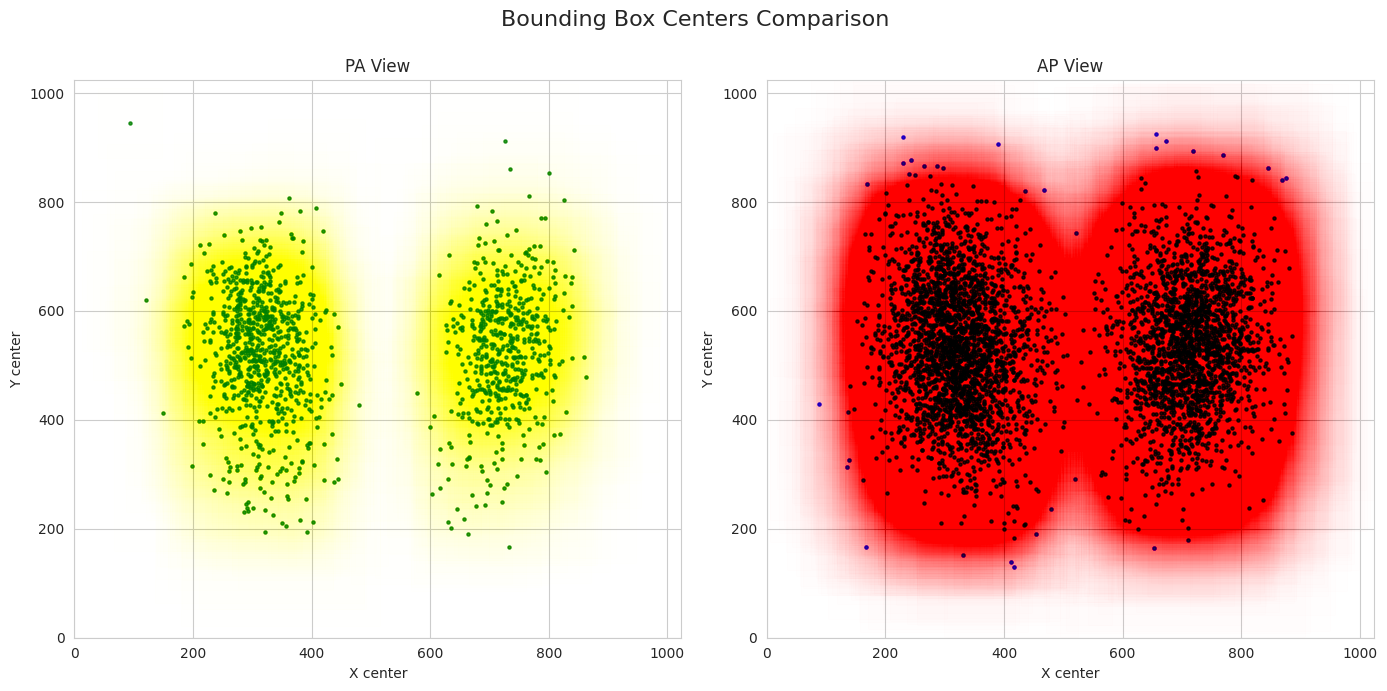

In [50]:
data_PA = bboxes[bboxes['ViewPosition'] == 'PA']
data_AP = bboxes[bboxes['ViewPosition'] == 'AP']

# Compare PA vs AP view bounding boxes
bboxes_scatter_dual(data_PA, data_AP,
    title1='PA View', title2='AP View',
    point_color1='green', box_color1='yellow',
    point_color2='blue', box_color2='red'
)

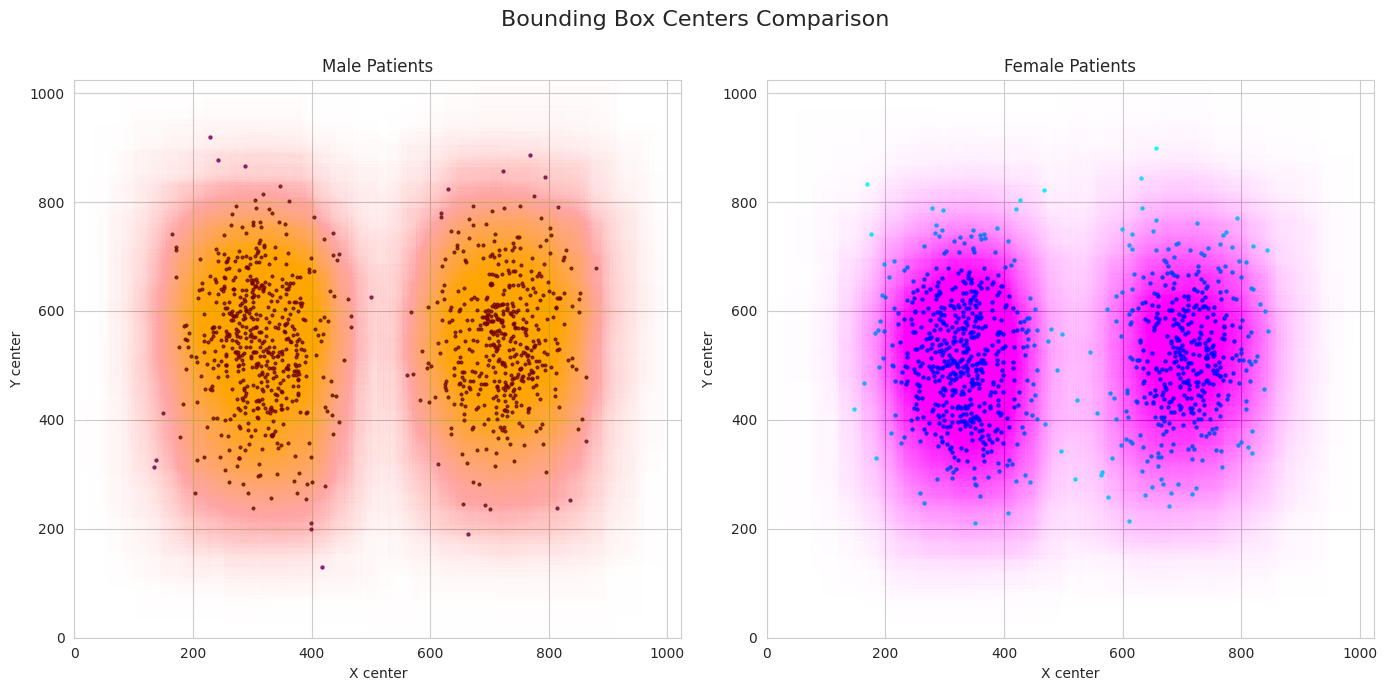

In [51]:
# Compare Male vs Female bounding boxes
data_male = bboxes[bboxes['PatientSex'] == 'M'].sample(1000)
data_female = bboxes[bboxes['PatientSex'] == 'F'].sample(1000)
bboxes_scatter_dual(
    data_male, data_female,
    title1='Male Patients', title2='Female Patients',
    point_color1='purple', box_color1='orange',
    point_color2='cyan', box_color2='magenta'
)

In [52]:
def plot_categorical_distributions(df, columns, hue=False, width=15, show_distribution=True):
    """
    Plots categorical count distributions with optional hue and percentage annotations.

    Parameters:
    - df: pandas DataFrame
    - columns: list of column names to plot
    - hue: column name for hue grouping (optional)
    - width: width of the entire plot
    - show_distribution: whether to annotate percentage labels on bars
    """
    
    # Display the columns and hue being plotted
    if hue:
        print(f"Generating plots for: {columns} with hue = '{hue}'")
    else:
        print(f"Generating plots for: {columns}")

    # Total number of samples for percentage calculation
    total = len(df)
    n_rows = len(columns)
    height_per_plot = 5
    fig, axes = plt.subplots(n_rows, 1, figsize=(width, n_rows * height_per_plot), constrained_layout=True)

    if n_rows == 1:
        axes = [axes]  # Ensure axes is always iterable

    for idx, column in enumerate(columns):
        ax = axes[idx]
        sns.countplot(data=df, x=column, hue=hue, ax=ax, palette='Set2')

        ax.set_title(f'Distribution of {column}', fontsize=14, fontweight='bold')
        ax.set_xlabel(column, fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.tick_params(axis='x', rotation=45)

        if show_distribution:
            for p in ax.patches:
                height = p.get_height()
                if height > 0 and total > 0:
                    ax.text(p.get_x() + p.get_width() / 2., height + total * 0.005,
                            f'{100 * height / total:.1f}%', ha='center', fontsize=10)

    plt.show()

Generating plots for: ['PatientSex'] with hue = 'class'


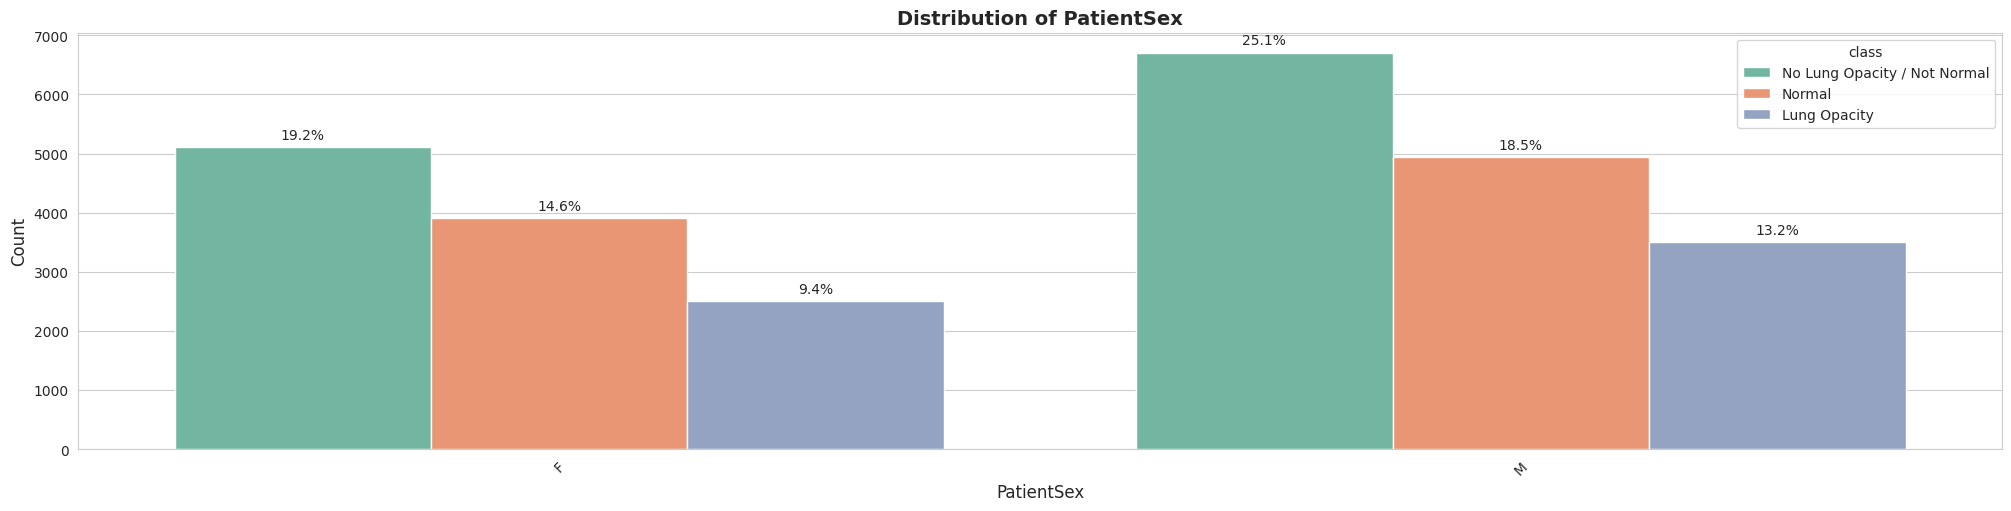

In [53]:
plot_categorical_distributions(
    df=df_pnemonia.drop_duplicates('patientId'), 
    columns=['PatientSex'], 
    hue='class', 
    width=20, 
    show_distribution=True
)


Generating plots for: ['PatientSex'] with hue = 'Target'


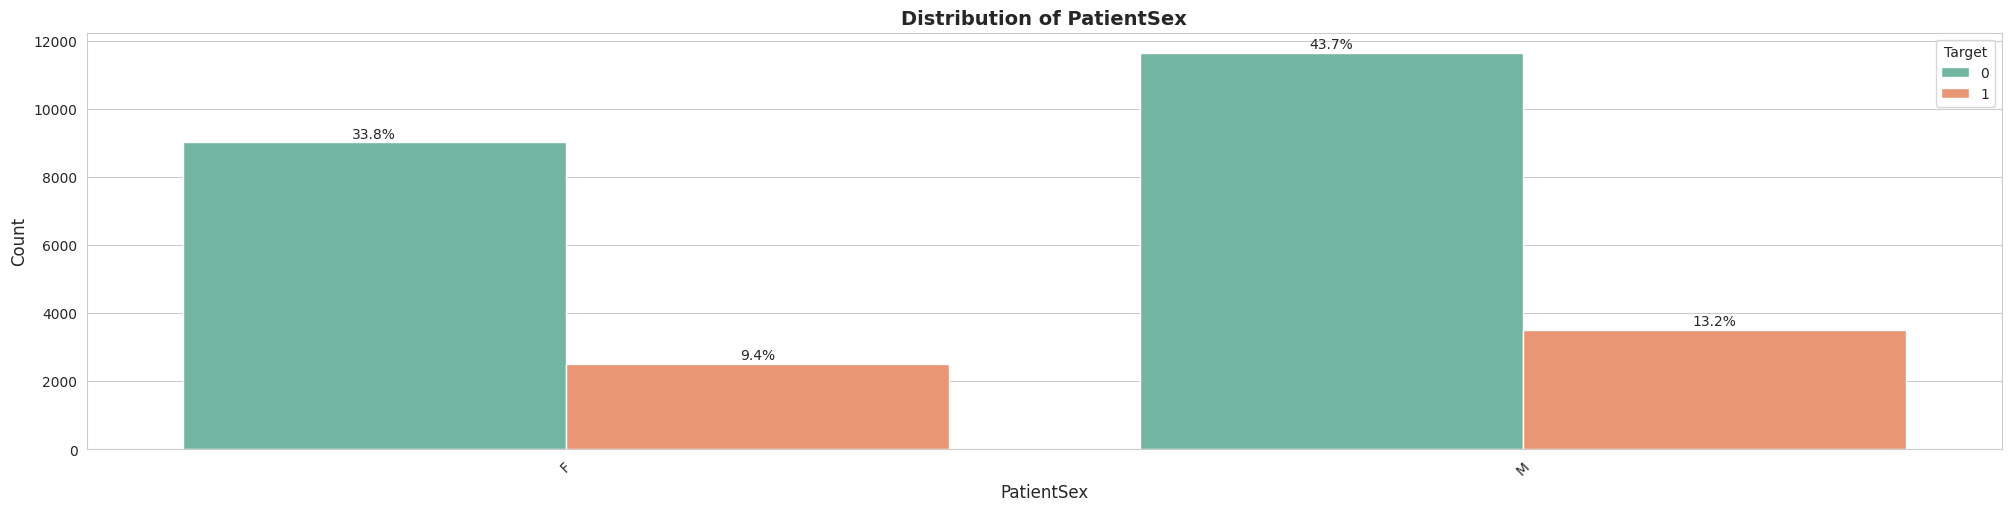

In [54]:
plot_categorical_distributions(
    df=df_pnemonia.drop_duplicates('patientId'), 
    columns=['PatientSex'], 
    hue='Target', 
    width=20, 
    show_distribution=True
)


Generating plots for: ['PatientAgeBins']


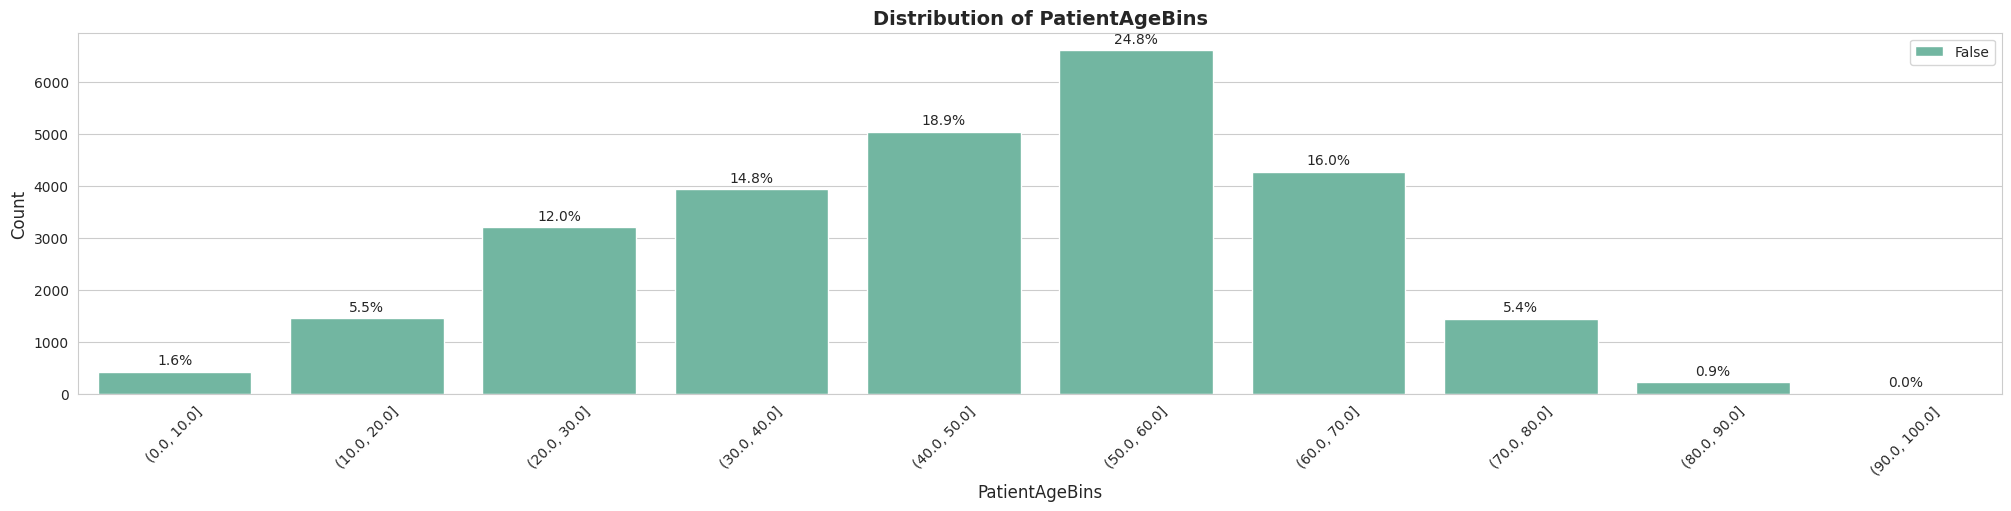

In [55]:
plot_categorical_distributions(
    df=df_pnemonia.drop_duplicates('patientId'), 
    columns=['PatientAgeBins'], 
    #hue='class', 
    width=20, 
    show_distribution=True
)


Generating plots for: ['PatientAgeBins'] with hue = 'Target'


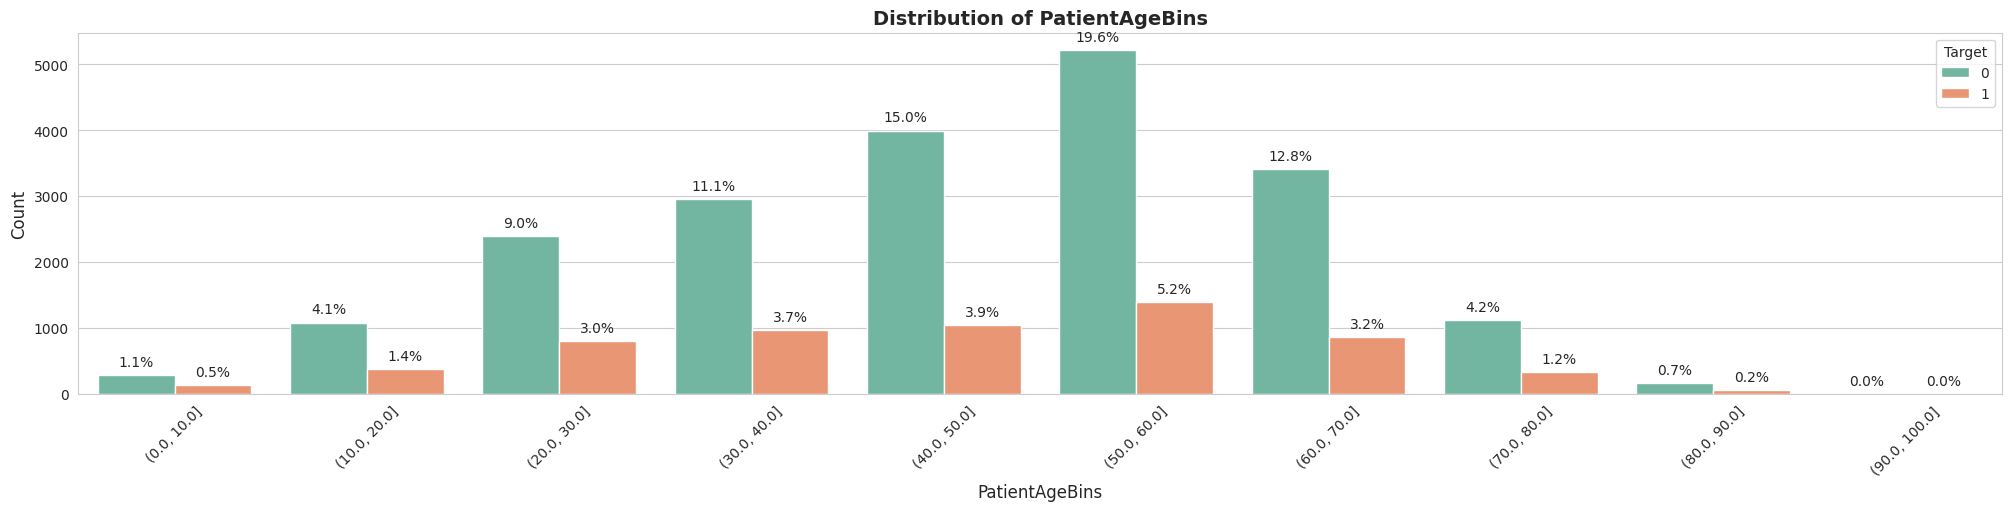

In [56]:
plot_categorical_distributions(
    df=df_pnemonia.drop_duplicates('patientId'), 
    columns=['PatientAgeBins'], 
    hue='Target', 
    width=20, 
    show_distribution=True
)


Generating plots for: ['PatientAgeBins'] with hue = 'class'


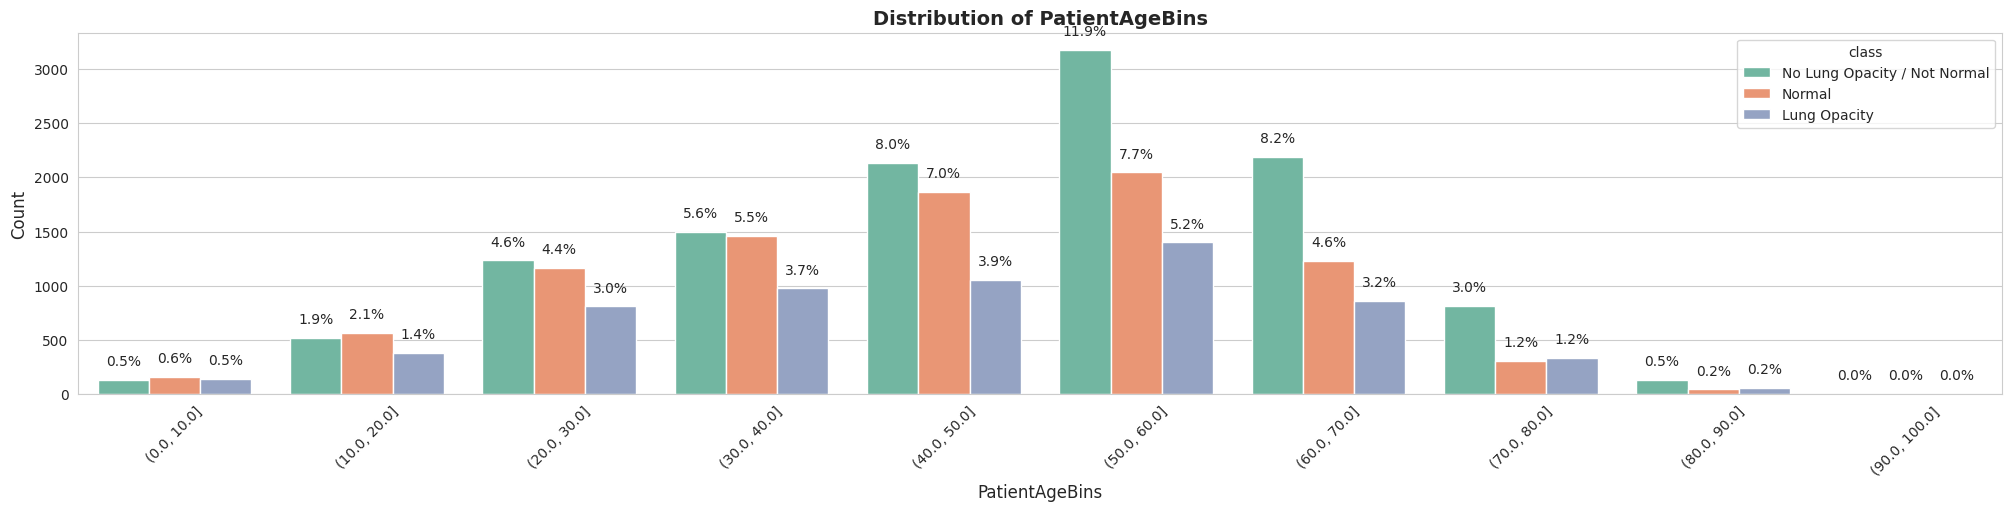

In [57]:
plot_categorical_distributions(
    df=df_pnemonia.drop_duplicates('patientId'), 
    columns=['PatientAgeBins'], 
    hue='class', 
    width=20, 
    show_distribution=True
)


In [58]:
data_age_19 = bboxes[bboxes['PatientAge'] < 20]
data_age_20_34 = bboxes[(bboxes['PatientAge'] >= 20) & (bboxes['PatientAge'] < 35)]
data_age_35_49 = bboxes[(bboxes['PatientAge'] >= 35) & (bboxes['PatientAge'] < 50)]
data_age_50_64 = bboxes[(bboxes['PatientAge'] >= 50) & (bboxes['PatientAge'] < 65)]
data_age_65 = bboxes[bboxes['PatientAge'] >= 65]

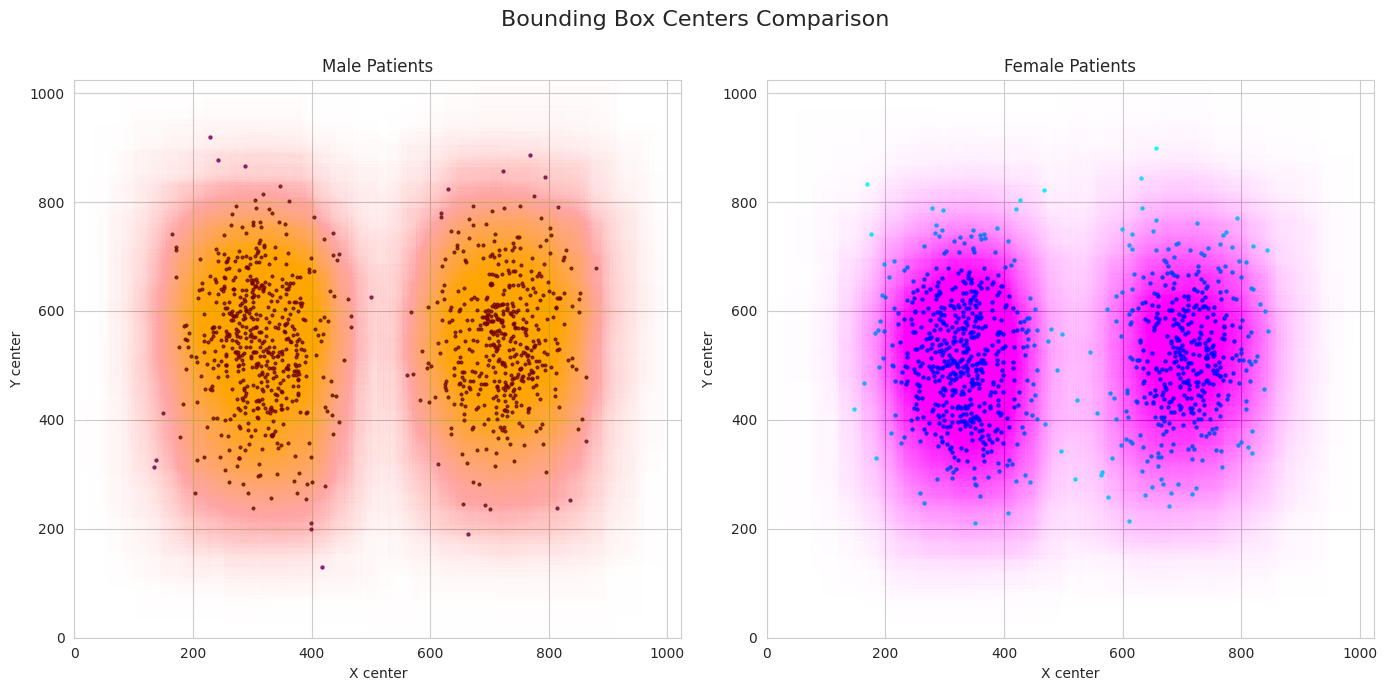

In [59]:
bboxes_scatter_dual(
    data_male, data_female,
    title1='Male Patients', title2='Female Patients',
    point_color1='purple', box_color1='orange',
    point_color2='cyan', box_color2='magenta'
)

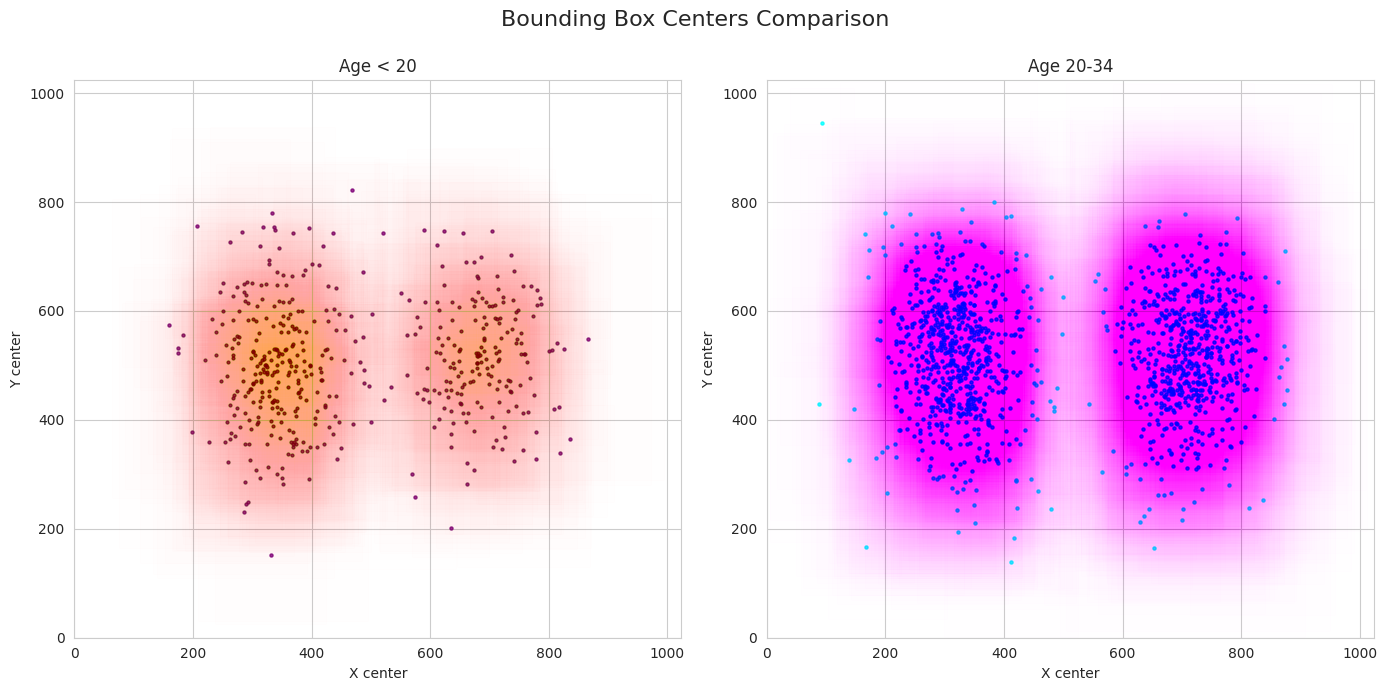

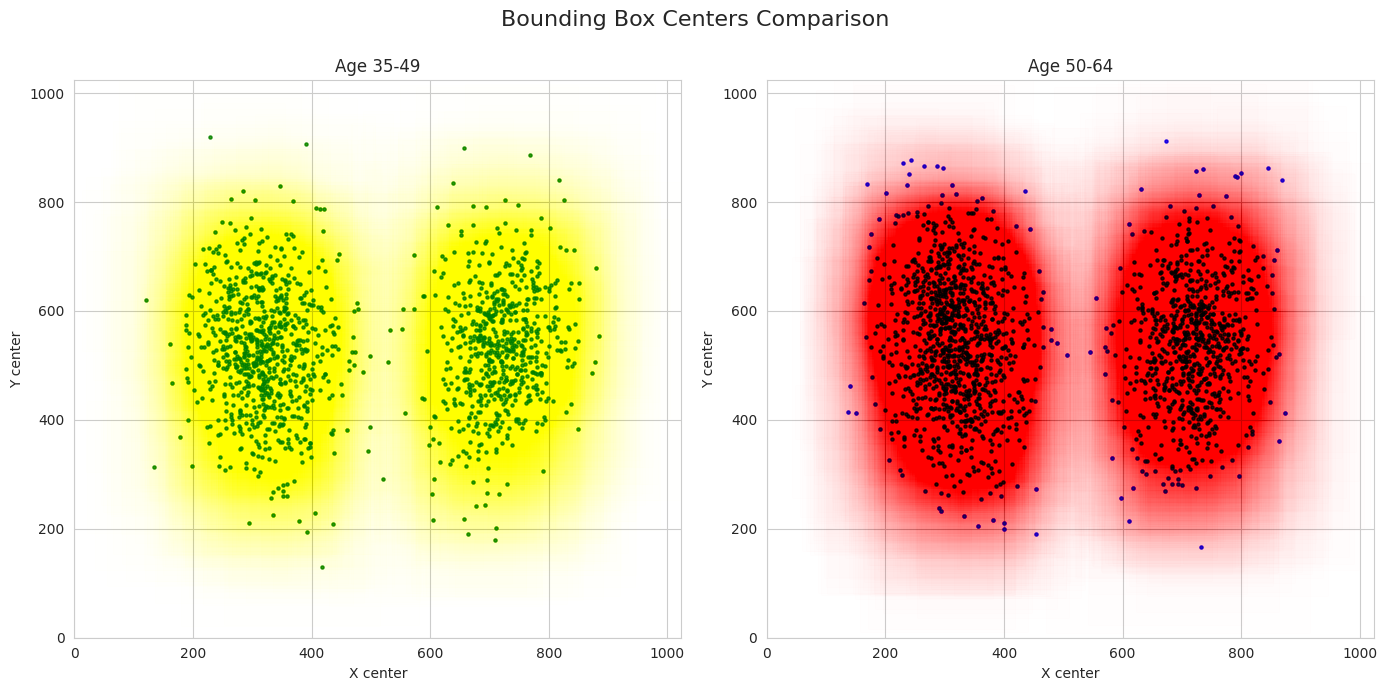

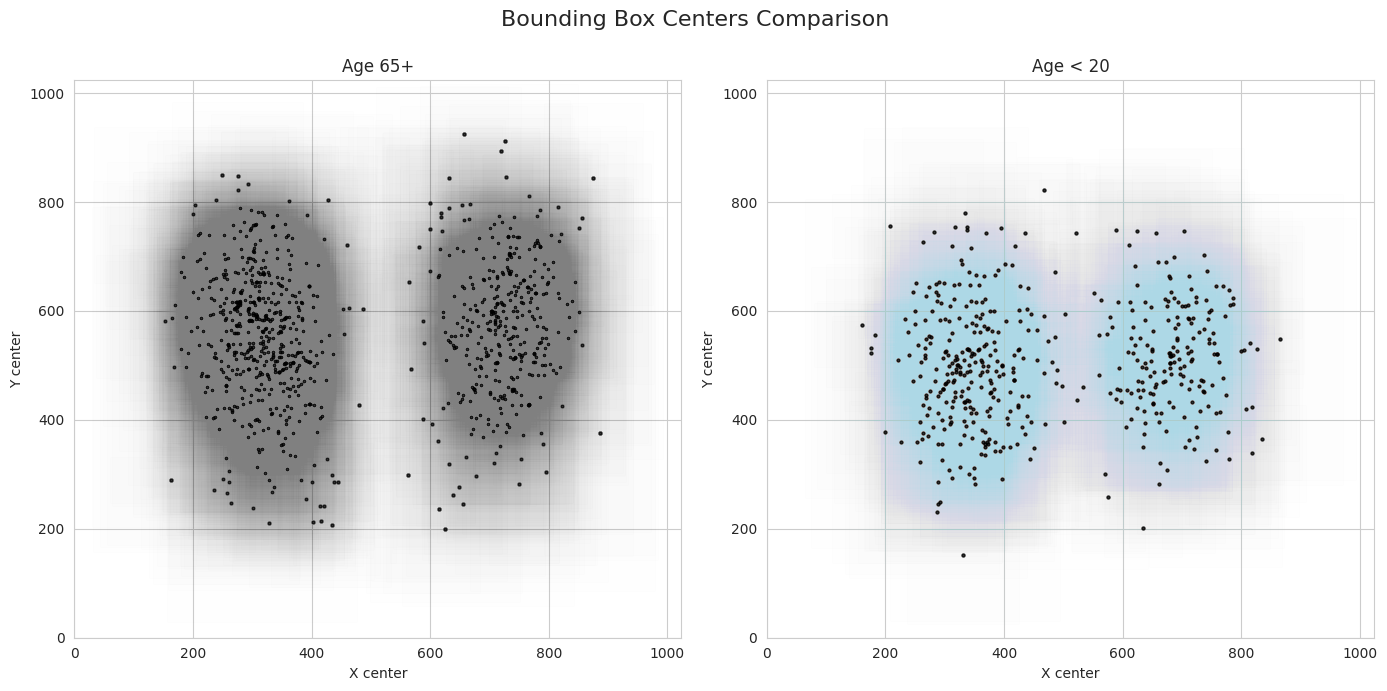

In [60]:
# Compare age < 20 vs 20-34
bboxes_scatter_dual(
    data_age_19, data_age_20_34,
    title1='Age < 20', title2='Age 20-34',
    point_color1='purple', box_color1='orange',
    point_color2='cyan', box_color2='magenta'
)

# Compare age 35-49 vs 50-64
bboxes_scatter_dual(
    data_age_35_49, data_age_50_64,
    title1='Age 35-49', title2='Age 50-64',
    point_color1='green', box_color1='yellow',
    point_color2='blue', box_color2='red'
)

# Compare age 65+ vs age < 20
bboxes_scatter_dual(
    data_age_65, data_age_19,
    title1='Age 65+', title2='Age < 20',
    point_color1='black', box_color1='gray',
    point_color2='black', box_color2='lightblue'
)


In [61]:
import os
import pydicom as dcm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def display_dicom_samples(sample_data, full_df, image_dir):
    """
    Display a 3x3 grid of DICOM images with bounding boxes and metadata.

    Parameters:
    - sample_data: pandas DataFrame subset with samples to display (e.g., 9 rows)
    - full_df: pandas DataFrame with full metadata including bounding box info
    - image_dir: directory path where DICOM images are stored

    Each subplot shows:
    - The DICOM image
    - Bounding boxes (if any) overlayed
    - Metadata such as Patient ID, Age, Sex, Body Part Examined, View Position,
      Modality, Target label, Class label, and bounding box coordinates.
    """
    
    # Convert sample_data rows to list of dicts for easy iteration
    sample_records = sample_data.to_dict(orient='records')

    # Setup figure with 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(16, 18))

    for i, record in enumerate(sample_records):
        # Construct the DICOM file path
        dicom_filename = f"{record['patientId']}.dcm"
        dicom_path = os.path.join(image_dir, dicom_filename)

        # Read the DICOM file once
        dicom_data = dcm.dcmread(dicom_path)

        # Filter all rows for the current patientId (could have multiple bounding boxes)
        patient_rows = full_df[full_df['patientId'] == record['patientId']]

        # Extract patient metadata from DICOM
        age = patient_rows['PatientAge'].unique()[0] if 'PatientAge' in patient_rows else 'N/A'
        sex = getattr(dicom_data, 'PatientSex', 'N/A')
        body_part = getattr(dicom_data, 'BodyPartExamined', 'N/A')
        view_pos = getattr(dicom_data, 'ViewPosition', 'N/A')
        modality = getattr(dicom_data, 'Modality', 'N/A')

        # Plot the image on the correct subplot
        ax = axes[i // 3, i % 3]
        ax.imshow(dicom_data.pixel_array, cmap=plt.cm.bone)
        ax.axis('off')

        # Compose the title with relevant info
        title = (
            f"ID: {record['patientId']}\n"
            f"Age: {age}, Sex: {sex}, Part: {body_part}, VP: {view_pos}, Modality: {modality}\n"
            f"Target: {record['Target']}, Class: {record['class']}\n"
            f"Window: {record['x']}:{record['y']}:{record['width']}:{record['height']}"
        )
        ax.set_title(title, fontsize=10)

        # Draw bounding boxes from all rows for this patient
        for _, box_row in patient_rows.iterrows():
            rect = Rectangle(
                (box_row['x'], box_row['y']),
                box_row['width'], box_row['height'],
                color='blue', alpha=0.15
            )
            ax.add_patch(rect)

    plt.tight_layout()
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\samya\\PyCharmProject\\Pneumonia-Detection_dataset\\data\\stage_2_train_images/f517aad3-95b2-4807-8e93-e82042b98619.dcm'

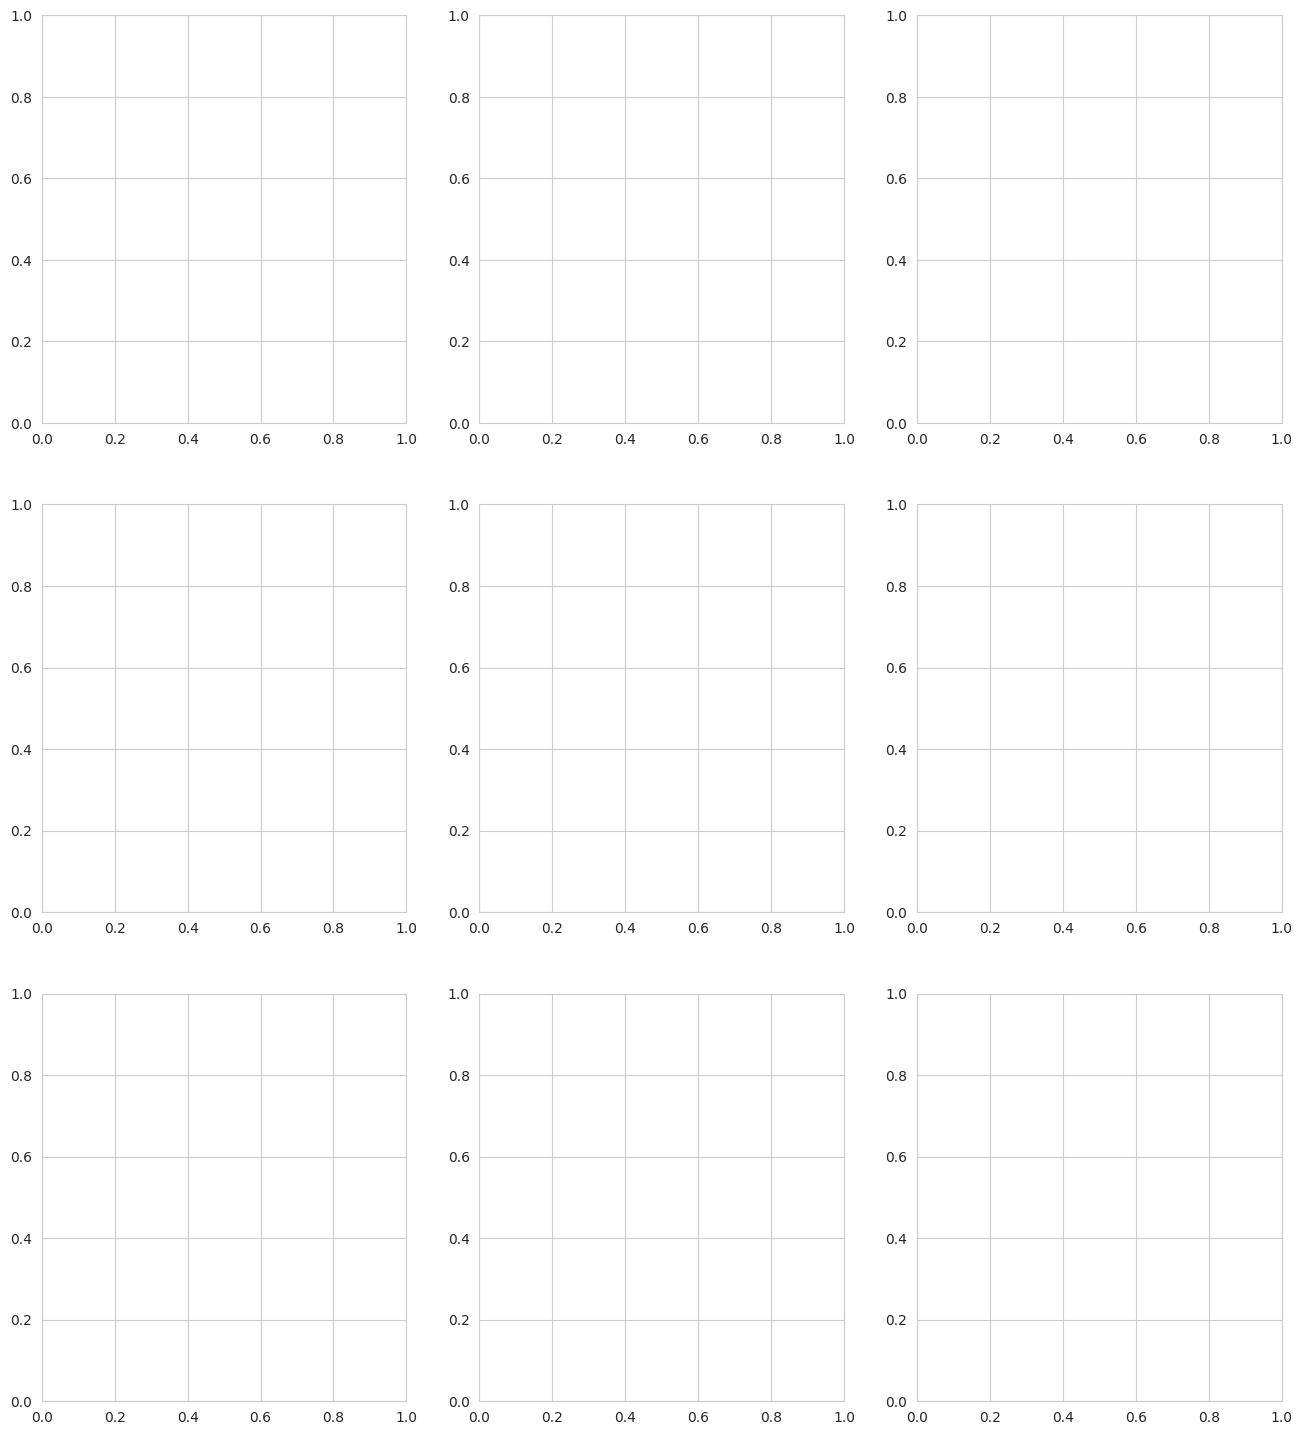

In [62]:
# Show 9 random samples without pneumonia (Target == 0)
display_dicom_samples(
    sample_data=df_pnemonia.loc[df_pnemonia['Target'] == 0].sample(9),
    full_df=df_pnemonia,
    image_dir=r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
)



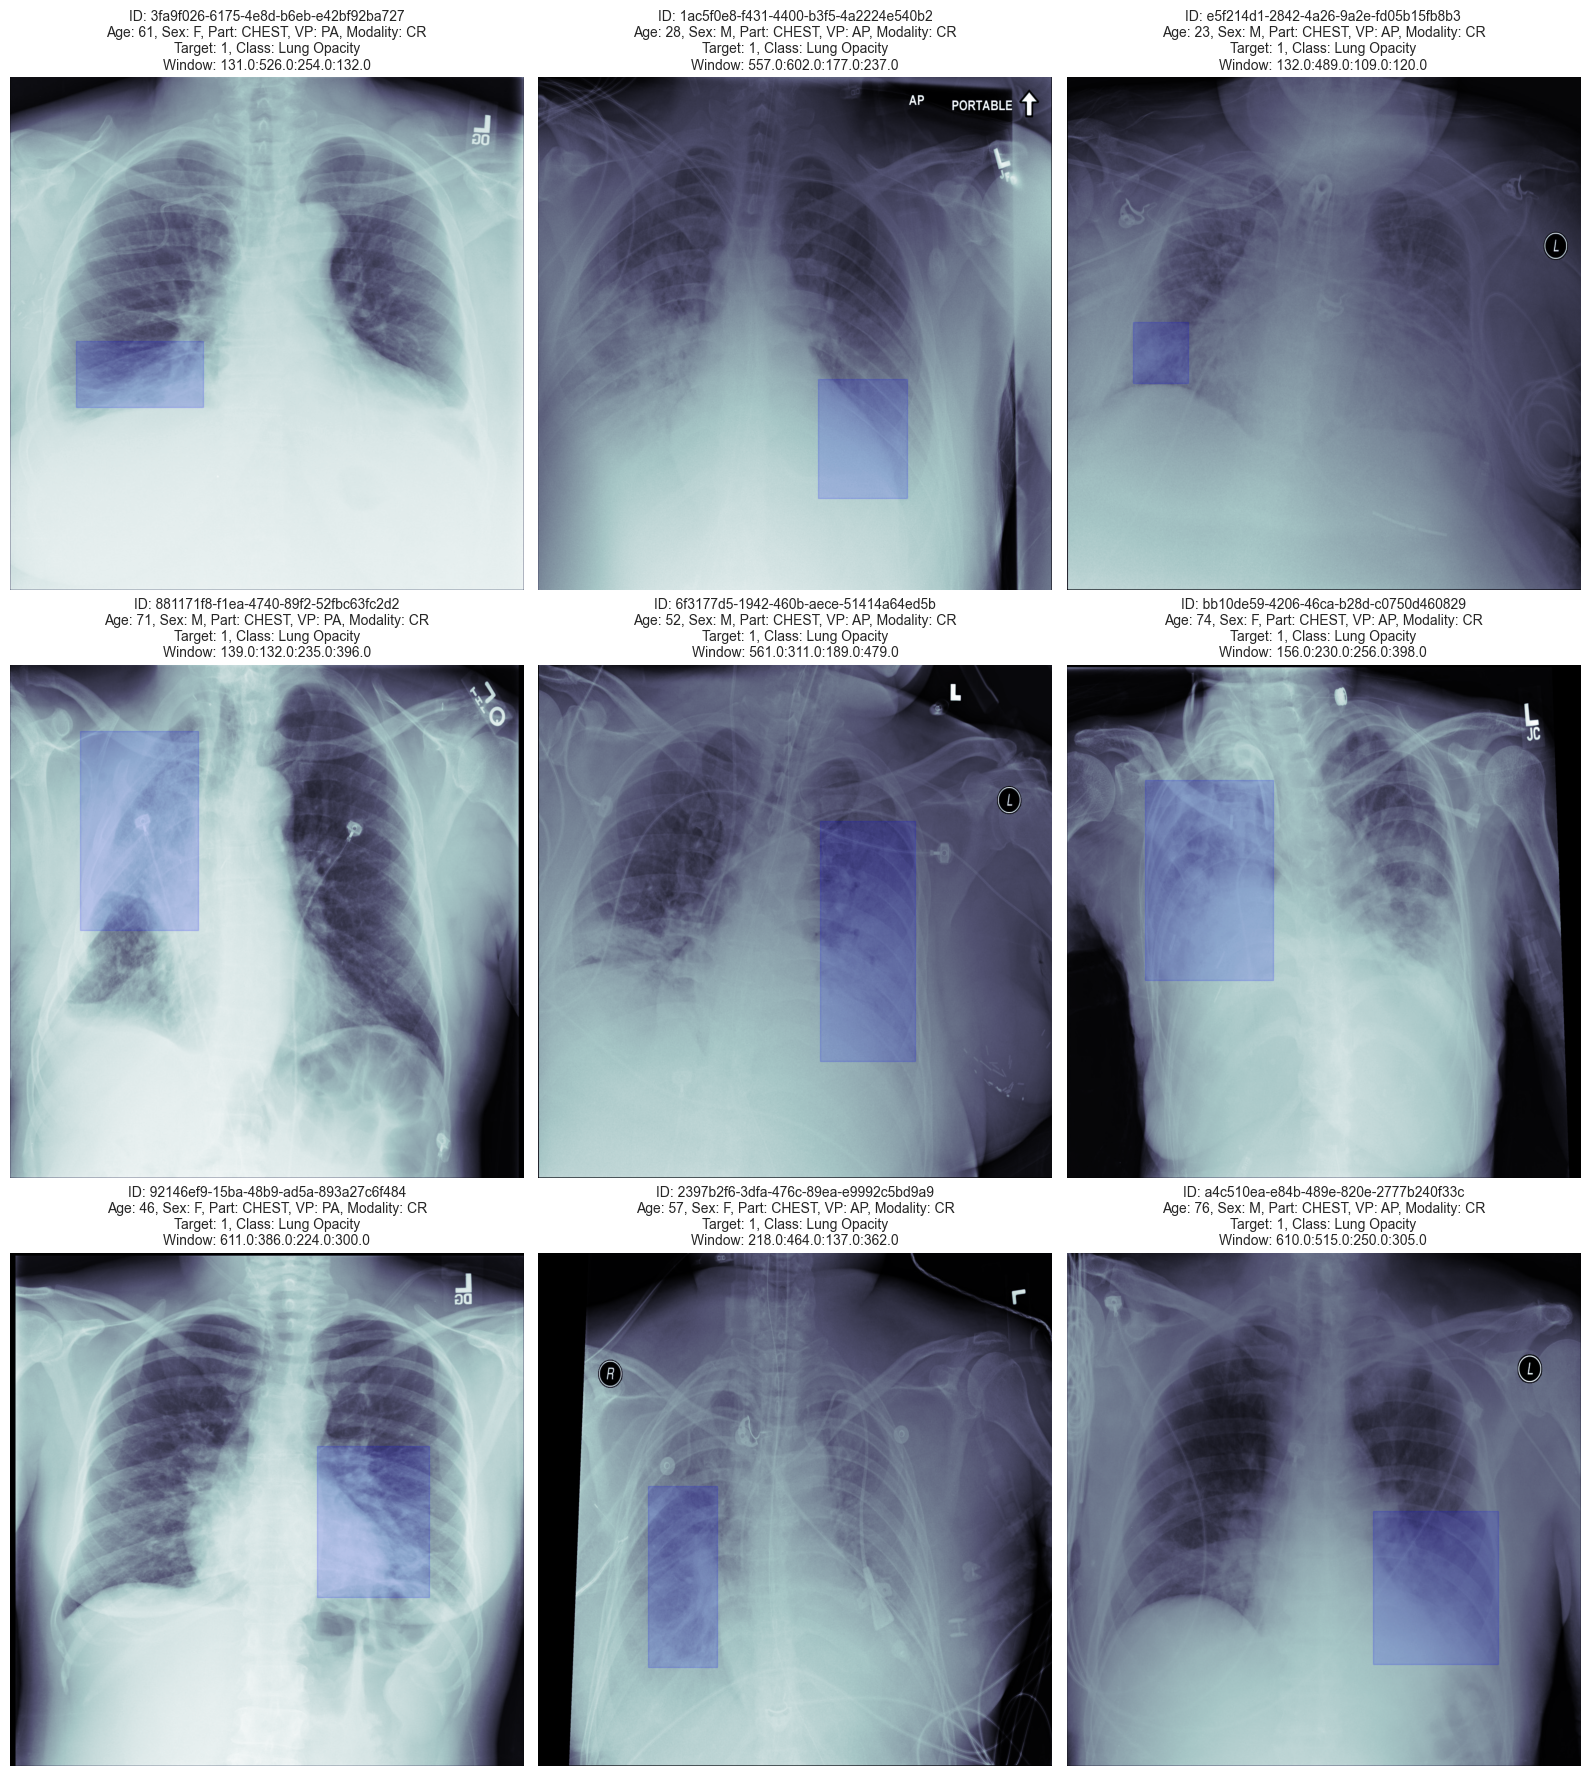

In [ ]:
# Show 9 random samples with pneumonia (Target == 1)
display_dicom_samples(
    sample_data=df_pnemonia.loc[df_pnemonia['Target'] == 1].sample(9),
    full_df=df_pnemonia,
    image_dir=r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
)